# Handwritten Digit Classification using Random Forest

This notebook performs digit recognition on the MNIST dataset by:
1. Loading the digits dataset (8×8 pixel images)
2. Visualising sample digit images in a grid
3. Training a Random Forest Classifier with 1000 estimators
4. Evaluating model performance with a confusion matrix

Random Forest is used as an ensemble method to achieve high accuracy
in digit recognition. The confusion matrix reveals which digit pairs
are most commonly confused.

## Load the Dataset

The sklearn digits dataset contains 1,797 samples, each a flattened 8×8
grayscale image (64 features) of a handwritten digit from 0 to 9.

In [1]:
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the digits dataset
digits, labels = load_digits(return_X_y=True)

## Visualise Sample Digits

The first 64 samples are displayed in an 8×8 grid. Each image is reshaped
from its flat 64-element vector back to an 8×8 pixel array.

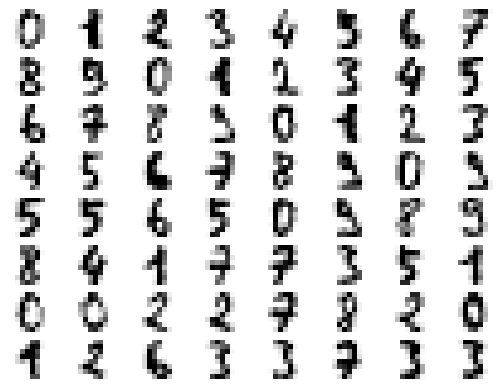

In [2]:
# Set up the figure
fig = plt.figure()  # Create a new figure

# Plot the digits: each image is 8x8 pixels
for i in range(64):
   ax = fig.add_subplot(8, 8, i + 1)  # Add a subplot to the figure
   ax.axis("off")                     # Turn off the axis
   ax.imshow(digits[i].reshape(8, 8), cmap="Greys")  # Display the image
plt.show()

## Train/Test Split and Model Training

The dataset is split 75/25 into training and test sets. A Random Forest
with 1,000 decision trees is then fitted on the training data.

In [3]:
# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(digits, labels, random_state=0)

# Create a random forest classifier with 1000 trees
model = RandomForestClassifier(n_estimators=1000)
model.fit(X_train, Y_train)  # Train the model
ypred = model.predict(X_test)  # Make predictions on the test set

## Confusion Matrix

The confusion matrix shows, for each true digit class, how many samples
were predicted as each class. Off-diagonal entries are misclassifications.
The matrix is transposed so rows represent predicted labels and columns
represent true labels.

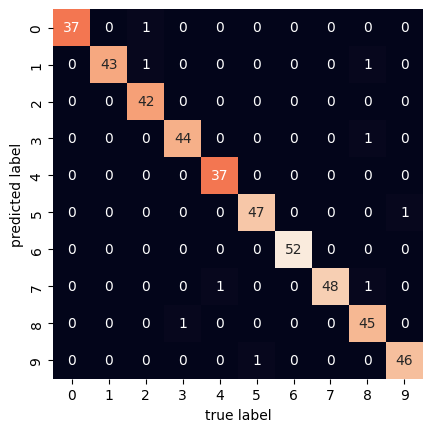

In [4]:
# Compute the confusion matrix
mat = confusion_matrix(Y_test, ypred)

# Plot the confusion matrix as a heatmap
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()